## Per-event Analysis

In [5]:
import pandas as pd

SAVE = False #set to True, if would save windows that not exceed cumulative SoC thresholds
if SAVE:
    output_path = "./Data_saved/kl_scheduling/allRows_vin1/valid_data_no_penalty_v2.csv"

# --- Load the CSV ---
df = pd.read_csv("./Data_saved/kl_scheduling/allRows_vin1/valid_data_no_penalty.csv")
#df = pd.read_csv(f'./Data_saved/kl_scheduling/allRows_vin2/Generated_data_NO_shuffle/valid_data_no_penalty.csv')

# --- Split into windows of 10 rows ---
window_size = 10
windows = [df.iloc[i:i+window_size].reset_index(drop=True)
           for i in range(0, len(df), window_size)]

results = []

# --- Analyze each window ---
for idx, w in enumerate(windows):
    # Detect where the sign of 'charge' changes (positive <-> negative)
    sign_change = (w['charge'].gt(0) != w['charge'].gt(0).shift()).cumsum()

    # Group by consecutive same-sign segments
    groups = w.groupby(sign_change)['charge'].sum().reset_index(drop=True)

    # Extract maximum positive and minimum negative consecutive sums
    max_cum = groups[groups > 0].max() if (groups > 0).any() else 0
    min_cum = groups[groups < 0].min() if (groups < 0).any() else 0

    # Check thresholds
    min_threshold = -95
    max_threshold = 95
    under_threshold = min_cum < min_threshold
    over_threshold = max_cum > max_threshold

    results.append({
        "window_id": idx,
        "min_cumulative": min_cum,
        "max_cumulative": max_cum,
        "under_threshold": under_threshold,
        "over_threshold": over_threshold,
    })

# --- Convert to DataFrame ---
summary = pd.DataFrame(results)

# --- Find extreme windows ---
min_row = summary.loc[summary['min_cumulative'].idxmin()]
max_row = summary.loc[summary['max_cumulative'].idxmax()]

# --- Count and list thresholds ---
under_threshold_windows = summary.loc[summary['under_threshold'], 'window_id'].tolist()
over_threshold_windows = summary.loc[summary['over_threshold'], 'window_id'].tolist()

print("\n=== 🔋 SUMMARY RESULTS ===")
print(f"Total windows analyzed: {len(summary)}")

print("\n🧩 Window with largest negative sequence (lowest min_cumulative):")
print(min_row)

print("\n⚡ Window with largest positive sequence (highest max_cumulative):")
print(max_row)

print(f"\n🚨 Under {min_threshold} check:")
if under_threshold_windows:
    print(f"  - Found {len(under_threshold_windows)} window(s) below {min_threshold} → IDs: {under_threshold_windows}")
else:
    print(f"  - None dropped below {min_threshold}.")

print(f"\n⚠️ Over {max_threshold} check:")
if over_threshold_windows:
    print(f"  - Found {len(over_threshold_windows)} window(s) above {max_threshold} → IDs: {over_threshold_windows}")
else:
    print(f"  - None exceeded {max_threshold}.")

print("\n==========================\n")

if SAVE:
    # --- ✅ Filter out windows that cross thresholds ---
    valid_windows = [
        w for i, w in enumerate(windows)
        if i not in under_threshold_windows and i not in over_threshold_windows
    ]
    


    # --- Combine valid windows and export ---
    if valid_windows:
        df_selected = pd.concat(valid_windows, ignore_index=True)
        df_selected.to_csv(output_path, index=False)
        print(f"✅ Saved filtered dataset with {len(df_selected)} rows to:\n{output_path}")
    else:
        print("⚠️ No valid windows left after filtering.")


=== 🔋 SUMMARY RESULTS ===
Total windows analyzed: 779

🧩 Window with largest negative sequence (lowest min_cumulative):
window_id                374
min_cumulative    -136.27122
max_cumulative           0.0
under_threshold         True
over_threshold         False
Name: 374, dtype: object

⚡ Window with largest positive sequence (highest max_cumulative):
window_id                 42
min_cumulative    -31.880464
max_cumulative     58.077129
under_threshold        False
over_threshold         False
Name: 42, dtype: object

🚨 Under -95 check:
  - Found 40 window(s) below -95 → IDs: [10, 26, 51, 53, 89, 111, 184, 228, 277, 287, 333, 356, 360, 374, 402, 410, 424, 431, 455, 458, 500, 513, 528, 550, 563, 605, 607, 610, 616, 619, 628, 653, 658, 676, 688, 691, 703, 752, 757, 758]

⚠️ Over 95 check:
  - None exceeded 95.


✅ Saved filtered dataset with 7390 rows to:
./Data_saved/kl_scheduling/allRows_vin1/valid_data_no_penalty_v2.csv


## Windows selection

In [2]:
import pandas as pd
import numpy as np
import random
from typing import List, Tuple
from scipy.stats import gaussian_kde, entropy
import matplotlib.lines as mlines
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator



class SmartDistributionBalancedSelector:
    """
    ⚡ Enhanced adaptive selector (v2 - per-batch similarity):
    - Ensures batch-wise charge/discharge ratio ≈ 1.0 ± tol
    - Computes similarity of each batch vs. original KDE (not cumulative)
    - Accepts ratio-valid batches even if similarity is low
    - Progressive tolerance relaxation (adaptive)
    - Transparent logging of per-batch stats
    """

    def __init__(self, windows: List[pd.DataFrame],
                 original_net_charges: List[float],
                 batch_size: int = 120,
                 ratio_tolerance: float = 0.02,
                 net_charge_range: Tuple[float, float] = (-70.5, 62.3)):
        self.windows = windows
        self.batch_size = batch_size
        self.ratio_tolerance = ratio_tolerance
        self.net_charge_range = net_charge_range
        self.kde_original = gaussian_kde(original_net_charges)
        self.original_net_charges = np.array(original_net_charges)

        # Compute stats
        self.window_stats = []
        for i, w in enumerate(windows):
            net_charge = w['charge'].sum()
            charging = w[w['charge'] > 0]['charge'].sum()
            discharging = abs(w[w['charge'] < 0]['charge'].sum())
            ratio = charging / discharging if discharging > 0 else np.inf
            self.window_stats.append({
                'index': i,
                'net_charge': net_charge,
                'charging': charging,
                'discharging': discharging,
                'ratio': ratio,
                'balance': abs(ratio - 1.0)
            })

        # Filter valid windows
        self.valid_indices = [
            s['index'] for s in self.window_stats
            if net_charge_range[0] <= s['net_charge'] <= net_charge_range[1]
        ]

        print(f"\n📊 Selector initialized:")
        print(f"   Total windows: {len(windows)}")
        print(f"   Valid pool: {len(self.valid_indices)}")
        print(f"   Batch size: {batch_size}")
        print(f"   Base tolerance: ±{ratio_tolerance:.3f}")

    # --------------------------------------------------------
    def _compute_batch_ratio(self, indices: List[int]) -> float:
        total_ch = sum(self.window_stats[i]['charging'] for i in indices)
        total_dis = sum(self.window_stats[i]['discharging'] for i in indices)
        return total_ch / total_dis if total_dis > 0 else np.inf

    # --------------------------------------------------------
    def _distribution_similarity(self, net_charges: List[float]) -> float:
        """Measure similarity between given net charges and original KDE."""
        if len(net_charges) < 5:
            return -np.inf
        kde_selected = gaussian_kde(net_charges)
        x_eval = np.linspace(-100, 100, 200)
        p_orig = self.kde_original(x_eval)
        p_sel = kde_selected(x_eval)
        kl = entropy(p_orig, p_sel)  # lower KL → better
        return -kl  # higher (less negative) = more similar

    # --------------------------------------------------------
    def _try_form_batches(self, target_batches: int, tol: float):
        from bisect import bisect_left
    
        sorted_windows = sorted(self.valid_indices,
                                key=lambda i: self.window_stats[i]['net_charge'])
        pool = sorted_windows.copy()
        selected_batches = []
        batch_sims = []
    
        target_mean = 0.0
        target_std = np.std(self.original_net_charges) 
    
        print(f"\n🧩 Attempting to form {target_batches} batches | tolerance ±{tol:.3f}")
        print("--------------------------------------------------------------")
    
        found_full_batch = False  # ✅ track if we’ve ever formed a complete 120 batch
    
        while len(pool) >= 10:  # don’t try with very small leftover sets
            batch = None
            net_charges_sorted = np.array([self.window_stats[i]['net_charge'] for i in pool])
    
            # 🎯 Try to form a full 120-window batch first
            if len(pool) >= self.batch_size:
                size = self.batch_size
                target_values = np.random.normal(target_mean, target_std, size)
                target_values = np.clip(target_values,
                                        self.net_charge_range[0],
                                        self.net_charge_range[1])
                target_values.sort()
    
                temp_pool = pool.copy()
                chosen = []
    
                for val in target_values:
                    if len(temp_pool) == 0:
                        break
                    idx_closest = np.argmin(np.abs(net_charges_sorted - val))
                    chosen_window = temp_pool[idx_closest]
                    chosen.append(chosen_window)
    
                    temp_pool.pop(idx_closest)
                    net_charges_sorted = np.delete(net_charges_sorted, idx_closest)
    
                # Evaluate batch
                batch_net_charges = [self.window_stats[i]['net_charge'] for i in chosen]
                batch_ratio = self._compute_batch_ratio(chosen)
                batch_mean = np.mean(batch_net_charges)
                batch_similarity = self._distribution_similarity(batch_net_charges)
    
                if (1.0 - tol <= batch_ratio <= 1.0 + tol) and abs(batch_mean) < 2.0:
                    found_full_batch = True
                    batch = chosen
                    pool = temp_pool
                    print(f"   ✅ Batch accepted | size={len(batch)} | ratio={batch_ratio:.4f} | sim={batch_similarity:.4f}\n")
                    selected_batches.append(batch)
                    batch_sims.append(batch_similarity)
                    continue  # try to form next batch (maybe partial later)
                else:
                    print(f"   ⚠️ Full batch failed | ratio={batch_ratio:.4f} | mean={batch_mean:.2f}")
    
            # 🧩 If we found at least one complete batch before → allow partials now
            if found_full_batch:
                for size in range(self.batch_size - 1, 9, -5):  # e.g. 119,114,...,10
                    if len(pool) < size:
                        continue
                    target_values = np.random.normal(target_mean, target_std, size)
                    target_values = np.clip(target_values,
                                            self.net_charge_range[0],
                                            self.net_charge_range[1])
                    target_values.sort()
    
                    temp_pool = pool.copy()
                    net_charges_sorted = np.array([self.window_stats[i]['net_charge'] for i in pool])
                    chosen = []
    
                    for val in target_values:
                        if len(temp_pool) == 0:
                            break
                        idx_closest = np.argmin(np.abs(net_charges_sorted - val))
                        chosen_window = temp_pool[idx_closest]
                        chosen.append(chosen_window)
                        temp_pool.pop(idx_closest)
                        net_charges_sorted = np.delete(net_charges_sorted, idx_closest)
    
                    # Evaluate batch
                    batch_net_charges = [self.window_stats[i]['net_charge'] for i in chosen]
                    batch_ratio = self._compute_batch_ratio(chosen)
                    batch_mean = np.mean(batch_net_charges)
                    batch_similarity = self._distribution_similarity(batch_net_charges)
    
                    if (1.0 - tol <= batch_ratio <= 1.0 + tol) and abs(batch_mean) < 2.0:
                        batch = chosen
                        pool = temp_pool
                        print(f"   ✅ Batch accepted | size={len(batch)} | ratio={batch_ratio:.4f} | sim={batch_similarity:.4f}\n")
                        selected_batches.append(batch)
                        batch_sims.append(batch_similarity)
                        break  # stop decreasing size once valid found
    
                # stop if no valid partial found
                if batch is None:
                    break
            else:
                # no valid full batch yet, stop (don’t even try partial)
                break
    
        print("--------------------------------------------------------------")
        print(f"🧮 Formed {len(selected_batches)} valid batches (full first, then partials)")
        if batch_sims:
            for i, s in enumerate(batch_sims, 1):
                print(f"   Batch {i}: similarity={s:.4f}")
        print("--------------------------------------------------------------")
    
        return selected_batches




    # --------------------------------------------------------
    def select_windows(self) -> Tuple[List[pd.DataFrame], List[int]]:
        possible_batches = len(self.valid_indices) // self.batch_size
        print(f"\n🚀 Selecting up to {possible_batches} batches adaptively...\n")

        all_batches = []
        for n_batches in range(possible_batches, 0, -1):
            for tol_factor in [1.0]:
                tol = self.ratio_tolerance * tol_factor
                batches = self._try_form_batches(n_batches, tol)
                if batches:
                    all_batches = batches
                    print(f"\n✅ Found {len(batches)} valid batches with tol=±{tol:.3f}")
                    break
            if all_batches:
                break

        if not all_batches:
            print("❌ No valid batches found — constraints too tight or imbalance too high.")
            return [], []

        selected_indices = [i for batch in all_batches for i in batch]
        selected_windows = [self.windows[i] for i in selected_indices]
        global_ratio = self._compute_batch_ratio(selected_indices)
        all_net_charges = [self.window_stats[i]['net_charge'] for i in selected_indices]

        print("\n📊 SELECTION SUMMARY")
        print("==============================================================")
        print(f"   Batches formed: {len(all_batches)}")
        for j, batch in enumerate(all_batches, 1):
            br = self._compute_batch_ratio(batch)
            bs = self._distribution_similarity([self.window_stats[i]['net_charge'] for i in batch])
            print(f"     • Batch {j}: size={len(batch)} | ratio={br:.4f} | similarity={bs:.4f}")
        print("--------------------------------------------------------------")
        print(f"   Total selected windows: {len(selected_indices)}")
        print(f"   Global ratio: {global_ratio:.4f}")
        print(f"   Net charge range: [{min(all_net_charges):.2f}, {max(all_net_charges):.2f}]")

        # Global (aggregate) similarity just for info
        similarity_score = self._distribution_similarity(all_net_charges)
        print(f"   Aggregate distribution similarity: {similarity_score:.4f}")
        print("==============================================================\n")

        return selected_windows, selected_indices

    # --------------------------------------------------------
    def export_selected_data(self, selected_windows: List[pd.DataFrame], output_path: str):
        if not selected_windows:
            print("⚠️ No windows to export.")
            return
        df_selected = pd.concat(selected_windows, ignore_index=True)
        df_selected.to_csv(output_path, index=False)
        print(f"💾 Exported {len(selected_windows)} selected windows to {output_path}")


### Main

📂 Loaded dataset: 739 complete windows

📊 Selector initialized:
   Total windows: 739
   Valid pool: 636
   Batch size: 100
   Base tolerance: ±0.020

🚀 Selecting up to 6 batches adaptively...


🧩 Attempting to form 6 batches | tolerance ±0.020
--------------------------------------------------------------
   ⚠️ Full batch failed | ratio=0.9234 | mean=-3.93
--------------------------------------------------------------
🧮 Formed 0 valid batches (full first, then partials)
--------------------------------------------------------------

🧩 Attempting to form 5 batches | tolerance ±0.020
--------------------------------------------------------------
   ⚠️ Full batch failed | ratio=0.9734 | mean=-1.30
--------------------------------------------------------------
🧮 Formed 0 valid batches (full first, then partials)
--------------------------------------------------------------

🧩 Attempting to form 4 batches | tolerance ±0.020
--------------------------------------------------------------
  

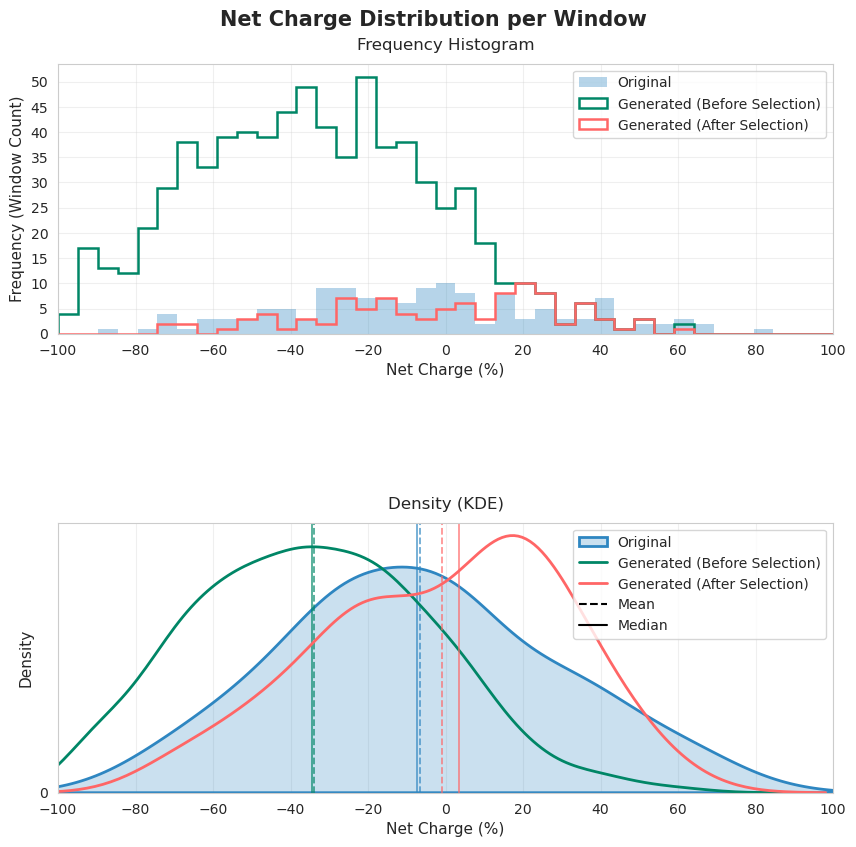


SELECTION SUMMARY
Selected 100 windows


In [5]:
# ============================================================
# 📊 PLOTTING FUNCTION
# ============================================================

def plot_net_charge_distributions_full(df_original: pd.DataFrame,
                                       generated_df: pd.DataFrame,
                                       selected_windows: list[pd.DataFrame],
                                       seq_len: int = 10,
                                       start_window: int = 0,
                                       end_window: int = 240):

    df_original['charge'] = df_original['end_soc'] - df_original['soc']

    orig_windows = [
        df_original.iloc[i:i + seq_len]
        for i in range(0, len(df_original), seq_len)
        if len(df_original.iloc[i:i + seq_len]) == seq_len
    ]
    orig_net_charges = [w['charge'].sum() for w in orig_windows]

    gen_windows = [
        generated_df.iloc[i:i + seq_len]
        for i in range(0, len(generated_df), seq_len)
        if len(generated_df.iloc[i:i + seq_len]) == seq_len
    ]
    gen_net_charges = [w['charge'].sum() for w in gen_windows]
    gen_net_charges = [x for x in gen_net_charges if -100 <= x <= 100]

    sel_net_charges = [w['charge'].sum() for w in selected_windows[start_window:end_window]]

    datasets = {
        "Original": (orig_net_charges, "#2E86C1"),
        "Generated (Before Selection)": (gen_net_charges, "#008666"),
        "Generated (After Selection)": (sel_net_charges, "#FF6666")
    }

    bins = np.linspace(-100, 100, 40)
    sns.set_style("whitegrid")

    fig, axes = plt.subplots(2, 1, figsize=(10, 9))
    fig.subplots_adjust(hspace=0.7, top=0.92)
    fig.suptitle("Net Charge Distribution per Window", fontsize=15, fontweight="bold")

    x_ticks = np.arange(-100, 120, 20)

    # =======================================================
    # 📊 FREQUENCY HISTOGRAM
    # =======================================================
    axes[0].hist(datasets["Original"][0], bins=bins, color=datasets["Original"][1],
                 alpha=0.35, label="Original", edgecolor='none')

    for name in ["Generated (Before Selection)", "Generated (After Selection)"]:
        data, color = datasets[name]
        axes[0].hist(data, bins=bins, histtype='step',
                     color=color, linewidth=1.8, label=name)

    axes[0].set_xlabel("Net Charge (%)", fontsize=11)
    axes[0].set_ylabel("Frequency (Window Count)", fontsize=11)
    axes[0].set_title("Frequency Histogram", fontsize=12, pad=10)
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    axes[0].set_xticks(x_ticks)
    axes[0].set_xlim(-100, 100)
    axes[0].yaxis.set_major_locator(MultipleLocator(5))

    # =======================================================
    # 📈 DENSITY (KDE) WITH MEAN & MEDIAN LINES
    # =======================================================
 
    for name, (data, color) in datasets.items():
        # KDE line
        sns.kdeplot(data, ax=axes[1],
                    color=color, lw=2,
                    fill=(name == "Original"), alpha=0.25 if name == "Original" else 1.0,
                    label=name)
    
        # Mean and median lines
        mean_val = np.mean(data)
        median_val = np.median(data)
        axes[1].axvline(mean_val, color=color, linestyle='--', linewidth=1.3, alpha=0.7)
        axes[1].axvline(median_val, color=color, linestyle='-', linewidth=1.3, alpha=0.7)
    
    # Create custom legend handles for mean/median
    mean_line = mlines.Line2D([], [], color='black', linestyle='--', label='Mean')
    median_line = mlines.Line2D([], [], color='black', linestyle='-', label='Median')
    
    # Combine dataset legend + mean/median legend
    handles, labels = axes[1].get_legend_handles_labels()
    axes[1].legend(handles + [mean_line, median_line],
                   labels + ['Mean', 'Median'],
                   fontsize=10)
    
    axes[1].set_xlabel("Net Charge (%)", fontsize=11)
    axes[1].set_ylabel("Density", fontsize=11)
    axes[1].set_title("Density (KDE)", fontsize=12, pad=10)
    axes[1].grid(True, alpha=0.3)
    axes[1].set_xticks(x_ticks)
    axes[1].set_xlim(-100, 100)
    axes[1].yaxis.set_major_locator(MultipleLocator(5))
    
    plt.show()




# ============================================================
# ⚙️ INTEGRATION WRAPPER
# ============================================================

def apply_smart_selection_to_dataset(original_data_path: str,
                                     data_path: str,
                                     seq_len: int = 10,
                                     batch_size: int = 120,
                                     ratio_range: Tuple[float, float] = (0.98, 1.02),
                                     net_charge_range: Tuple[float, float] = (-70.5, 62.3),
                                     output_path: str = None):

    random.seed(42)
    np.random.seed(42)

    df = pd.read_csv(data_path)
    windows = [df.iloc[i:i+seq_len] for i in range(0, len(df), seq_len)]
    windows = [w for w in windows if len(w) == seq_len]

    print(f"📂 Loaded dataset: {len(windows)} complete windows")

    df_original = pd.read_csv(original_data_path)
    orig_windows = [
        df_original.iloc[i:i + seq_len]
        for i in range(0, len(df_original), seq_len)
        if len(df_original.iloc[i:i + seq_len]) == seq_len
    ]

    selector = SmartDistributionBalancedSelector(
        windows=windows,
        original_net_charges=[(w['end_soc'] - w['soc']).sum() for w in orig_windows],
        batch_size=batch_size,
        ratio_tolerance=ratio_range[1] - 1.0,
        net_charge_range=net_charge_range
    )

    selected_windows, selected_indices = selector.select_windows()

    if output_path and selected_windows:
        selector.export_selected_data(selected_windows, output_path)

    plot_net_charge_distributions_full(
        df_original=df_original,
        generated_df=df,
        selected_windows=selected_windows,
        seq_len=seq_len,
        start_window=0,
        end_window=100
    )

    return selected_windows, selected_indices, selector


# ============================================================
# EXECUTION   
# ============================================================
              
if __name__ == "__main__":
    selected_windows, selected_indices, selector = apply_smart_selection_to_dataset(
        original_data_path='./datasets/vehicle_8_99632e+18.csv',
        data_path='./Data_saved/kl_scheduling/allRows_vin1/valid_data_no_penalty_v2.csv',
        seq_len=10,
        batch_size=100,
        ratio_range=(0.98, 1.02),
        net_charge_range=(-70.5, 62.3), #(-70.5, 62.3) are the (min,max) values in vin2; (-80.1, 73.7) for vin3
        #output_path='./Data_saved/kl_scheduling/allRows_vin1/selected_windows_balanced.csv'
    )

    print("\n" + "=" * 80)
    print("SELECTION SUMMARY")
    print("=" * 80)
    print(f"Selected {len(selected_windows)} windows")

## Try to have the longest sub-timeline reconstructed

🔋 Initializing timeline reconstructor with 120 windows
Window net charges: ['-61.0%', '-50.5%', '-48.9%', '-47.7%', '-45.0%', '-43.8%', '-41.6%', '-39.1%', '-38.6%', '-39.2%', '-37.5%', '-36.7%', '-35.1%', '-33.7%', '-33.2%', '-30.8%', '-30.3%', '-28.9%', '-28.6%', '-28.0%', '-27.2%', '-26.8%', '-26.0%', '-25.6%', '-25.6%', '-25.2%', '-24.4%', '-23.6%', '-22.6%', '-21.1%', '-17.3%', '-15.8%', '-14.1%', '-13.2%', '-10.9%', '-9.7%', '-8.5%', '-7.6%', '-6.7%', '-5.9%', '-5.1%', '-2.7%', '-1.9%', '-2.8%', '-1.0%', '-0.8%', '0.3%', '1.7%', '2.2%', '2.3%', '3.1%', '4.8%', '5.6%', '5.7%', '5.8%', '8.2%', '9.1%', '9.2%', '9.3%', '9.4%', '9.6%', '10.2%', '10.4%', '10.5%', '11.3%', '11.7%', '11.8%', '12.1%', '13.0%', '13.4%', '14.8%', '14.4%', '14.4%', '15.8%', '16.0%', '18.4%', '19.7%', '20.6%', '22.5%', '23.7%', '24.8%', '25.4%', '25.5%', '27.1%', '27.3%', '23.4%', '28.9%', '30.6%', '35.6%', '36.4%', '41.3%', '43.7%', '46.4%', '47.9%', '58.2%', '60.3%', '60.4%', '61.5%', '60.9%', '56.1%', '0.0

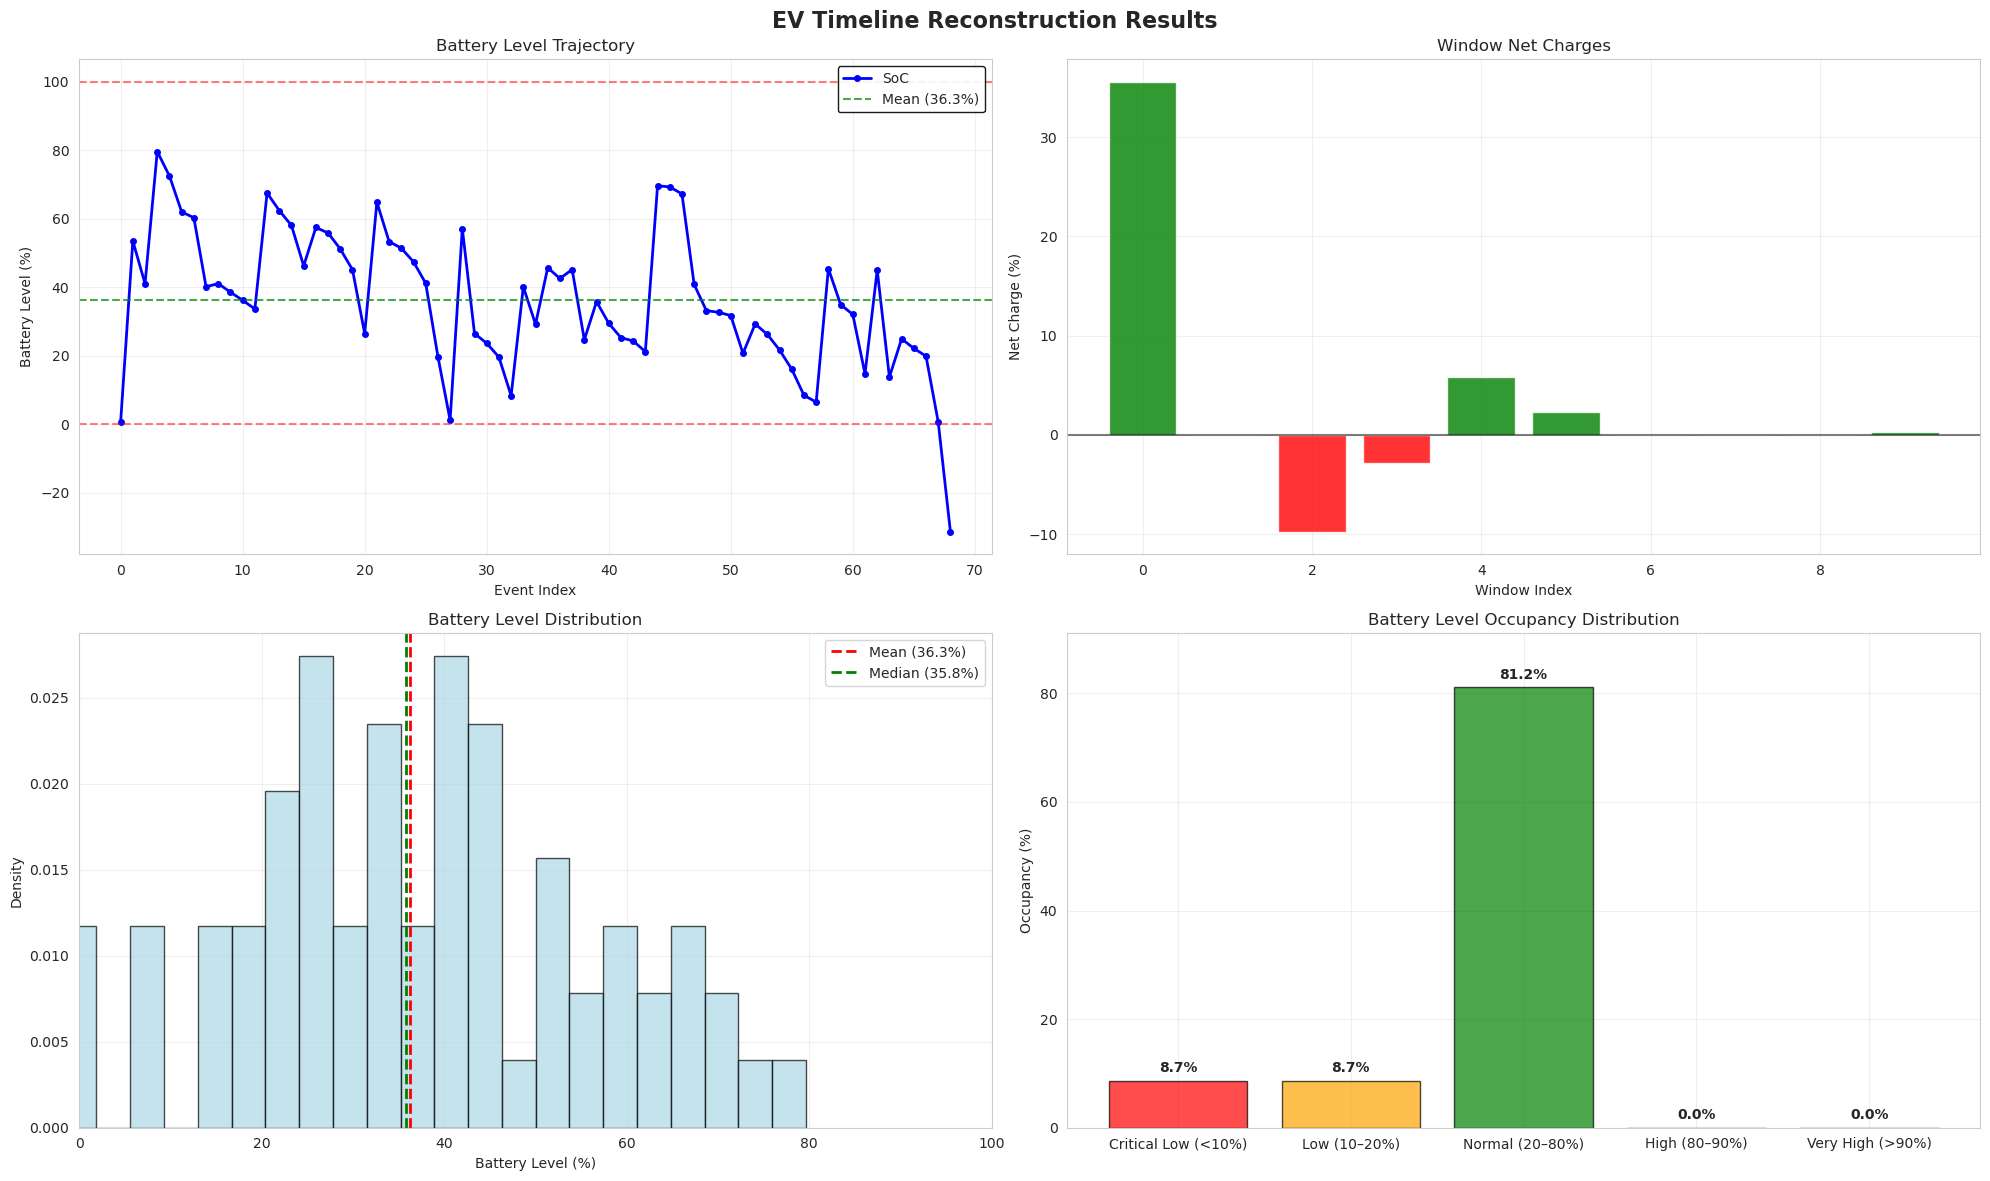


Sequence Analysis:
  Window sequence: [88, 109, 35, 43, 54, 49, 112, 119, 107, 46]
  Sequence length: 10
  Battery stability (low std is better): 20.56%
  Time in critical low battery (<10%): 10.1%
  Time in low battery (10–20%): 8.7%
  Time in normal battery zone (20–80%): 81.2%
  Time in high zone (80–90%): 0.0%
  Time in very high zone (>90%): 0.0%
  Charging windows: 4, Discharging windows: 2
  Total net charge: 31.4%

DETAILED VIOLATION ANALYSIS
ℹ️  Position 2 → 3: Window 35 doesn't end with charge, Window 43 starts with 360


In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import defaultdict, deque
import random
from typing import List, Tuple, Dict, Optional, Set
import heapq
from dataclasses import dataclass

random.seed(2025)
np.random.seed(2025)

@dataclass
class BatteryState:
    """Represents battery state at a point in time"""
    level: float  # Battery percentage (0-100)
    timestamp: int  # Relative time
    window_id: int  # Which window this state belongs to
    event_idx: int  # Position within window

class EVTimelineReconstructor:
    """
    Algorithm to reconstruct EV timeline from fragmented windows
    while respecting battery constraints (0% ≤ battery ≤ 100%)
    """
    
    def __init__(self, windows: List[pd.DataFrame], initial_battery_range=(0, 100),
                 min_soc: float = 0.0,
                 max_soc: float = 100.0,
                 different_mode_penalty: float = 10000.0,
                 # Tuning parameters for extreme windows
                 low_soc_threshold: float = 25.0,
                 high_soc_threshold: float = 75.0,
                 extreme_netcharge_threshold: float = 35.0,
                 preference_bonus: float = 500.0):
        """Initialize the reconstructor"""
        self.windows = windows
        self.n_windows = len(windows)
        self.initial_battery_range = initial_battery_range
        self.window_net_charges = [w['charge'].sum() for w in windows]

        self.min_soc = min_soc
        self.max_soc = max_soc
        self.different_mode_penalty = different_mode_penalty

        self.low_soc_threshold = low_soc_threshold
        self.high_soc_threshold = high_soc_threshold
        self.extreme_netcharge_threshold = extreme_netcharge_threshold
        self.preference_bonus = preference_bonus
        
        print(f"🔋 Initializing timeline reconstructor with {self.n_windows} windows")
        print(f"Window net charges: {[f'{x:.1f}%' for x in self.window_net_charges]}")
        print("Total net charge across all windows:", sum(self.window_net_charges))
        
        self.precompute_window_stats()

        
    def precompute_window_stats(self):
        """Precompute statistics for each window"""
        self.window_stats = []
        
        for i, window in enumerate(self.windows):
            stats = {
                'window_id': i,
                'net_charge': window['charge'].sum(),
                'min_intermediate_charge': 0,
                'max_intermediate_charge': 0,
                'total_duration': window['duration_minutes'].sum(),
                'total_km': window['km_driven'].sum(),
                'charge_events': (window['charge'] > 0).sum(),
                'discharge_events': (window['charge'] < 0).sum()
            }
            
            running_charge = 0
            min_charge, max_charge = 0, 0
            
            for charge in window['charge']:
                running_charge += charge
                min_charge = min(min_charge, running_charge)
                max_charge = max(max_charge, running_charge)
            
            stats['min_intermediate_charge'] = min_charge
            stats['max_intermediate_charge'] = max_charge
            
            self.window_stats.append(stats)

    def simulate_battery_trace(self, sequence: List[int], start_battery: float) -> List[float]:
        """Return the battery trace"""
        battery = start_battery
        trace = [battery]
        for window_id in sequence:
            window = self.windows[window_id]
            for _, event in window.iterrows():
                battery += event['charge']
                trace.append(battery)
        return trace

    def preference_bonus_for_placement(self, battery_before: float, net_charge: float) -> float:
        """
        Return a negative cost (bonus) if placement is sensible:
          - Low battery + high positive charge = bonus
          - High battery + high negative charge = bonus
        Otherwise return penalty for bad placements
        """
        if abs(net_charge) < self.extreme_netcharge_threshold:
            return 0.0

        scale = abs(net_charge) / max(self.extreme_netcharge_threshold, 1.0)
        
        # Good placements (bonus)
        if battery_before <= self.low_soc_threshold and net_charge > 0:
            return -self.preference_bonus * scale
        if battery_before >= self.high_soc_threshold and net_charge < 0:
            return -self.preference_bonus * scale

        # Bad placements (penalty)
        if battery_before <= self.low_soc_threshold and net_charge < 0:
            return self.preference_bonus * scale
        if battery_before >= self.high_soc_threshold and net_charge > 0:
            return self.preference_bonus * scale

        return 0.0

    def window_ends_with_charge_mode(self, window_id: int) -> Optional[str]:
        """Return the charge_mode if window ends with a charge, else None"""
        w = self.windows[window_id]
    
        # Safety check: empty window
        if w.empty:
            return None
    
        last_event = w.iloc[-1]
        if last_event.get('event') == 'charge':
            return str(last_event.get('charge_mode'))
        return None
    
    
    def window_starts_with_charge_mode(self, window_id: int) -> Optional[str]:
        """Return the charge_mode if window starts with a charge, else None"""
        w = self.windows[window_id]
    
        # Safety check: empty window
        if w.empty:
            return None
    
        first_event = w.iloc[0]
        if first_event.get('event') == 'charge':
            return str(first_event.get('charge_mode'))
        return None

    
    def check_consecutive_different_mode_violation(self, sequence: List[int]) -> Tuple[bool, int]:
        """Check if sequence has consecutive DIFFERENT-mode charge violations"""
        violations = 0
        for i in range(len(sequence) - 1):
            end_mode = self.window_ends_with_charge_mode(sequence[i])
            start_mode = self.window_starts_with_charge_mode(sequence[i + 1])
            
            if end_mode is not None and start_mode is not None and end_mode != start_mode:
                violations += 1
        
        return violations > 0, violations

    def algorithm_2_simulated_annealing(self, start_battery: float, 
                                      max_iterations: int = 20000,
                                      initial_temp: float = 100.0) -> Optional[List[int]]:
        """Standard Simulated Annealing """
        print("  Running Algorithm: Simulated Annealing...")
        
        def evaluate_sequence(sequence: List[int]) -> float:
            """Evaluate fitness with EXPONENTIAL penalties and preference bonuses"""
            battery = start_battery
            cost = 0.0
            
            for i, window_id in enumerate(sequence):
                stats = self.window_stats[window_id]

                # Different-mode penalty
                if i > 0:
                    prev_id = sequence[i - 1]
                    end_mode = self.window_ends_with_charge_mode(prev_id)
                    start_mode = self.window_starts_with_charge_mode(window_id)
                    if end_mode is not None and start_mode is not None and end_mode != start_mode:
                        cost += self.different_mode_penalty
                
                # Check constraints with EXPONENTIAL penalties
                min_battery = battery + stats['min_intermediate_charge']
                max_battery = battery + stats['max_intermediate_charge']
                
                if min_battery < self.min_soc:
                    violation = self.min_soc - min_battery
                    cost += 3000 * (violation ** 2)  # EXPONENTIAL
                if max_battery > self.max_soc:
                    violation = max_battery - self.max_soc
                    cost += 3000 * (violation ** 2)  # EXPONENTIAL
                
                # Preference bonus/penalty
                pref = self.preference_bonus_for_placement(battery, stats['net_charge'])
                cost += pref
                
                battery += stats['net_charge']
                cost += abs(battery - 50) * 0.05
            
            return cost
        
        def get_smart_neighbor(sequence: List[int]) -> List[int]:
            """Smart neighbor generation that targets problem areas"""
            
            # 30% of time: use constraint-aware swapping
            if random.random() < 0.3:
                battery = start_battery
                problem_positions = []
                
                for i, window_id in enumerate(sequence):
                    stats = self.window_stats[window_id]
                    min_battery = battery + stats['min_intermediate_charge']
                    max_battery = battery + stats['max_intermediate_charge']
                    
                    if min_battery < 0.0 or max_battery > self.max_soc:
                        problem_positions.append(i)
                    
                    battery += stats['net_charge']
                
                if problem_positions:
                    new_seq = sequence.copy()
                    problem_idx = random.choice(problem_positions)
                    window_id = sequence[problem_idx]
                    stats = self.window_stats[window_id]
                    
                    # Move high-charge windows earlier, high-discharge later
                    if stats['net_charge'] > self.extreme_netcharge_threshold:
                        new_pos = random.randint(0, max(1, len(new_seq) // 3))
                    elif stats['net_charge'] < -self.extreme_netcharge_threshold:
                        new_pos = random.randint(2 * len(new_seq) // 3, len(new_seq) - 1)
                    else:
                        new_pos = random.randint(0, len(new_seq) - 1)
                    
                    new_seq.insert(new_pos, new_seq.pop(problem_idx))
                    return new_seq
            
            # 30% of time: mode-aware swapping
            if random.random() < 0.5:
                has_violation, _ = self.check_consecutive_different_mode_violation(sequence)
                
                if has_violation:
                    violation_positions = []
                    for i in range(len(sequence) - 1):
                        end_mode = self.window_ends_with_charge_mode(sequence[i])
                        start_mode = self.window_starts_with_charge_mode(sequence[i + 1])
                        if end_mode is not None and start_mode is not None and end_mode != start_mode:
                            violation_positions.append(i)
                    
                    if violation_positions:
                        new_seq = sequence.copy()
                        violation_pos = random.choice(violation_positions)
                        other_pos = random.choice([p for p in range(len(new_seq)) 
                                                   if p not in [violation_pos, violation_pos + 1]])
                        new_seq[violation_pos + 1], new_seq[other_pos] = new_seq[other_pos], new_seq[violation_pos + 1]
                        return new_seq
            
            # Standard moves
            neighbor_type = random.choice(['swap', 'insert'])
            new_seq = sequence.copy()
            
            if neighbor_type == 'insert':
                i = random.randint(0, len(new_seq) - 1)
                element = new_seq.pop(i)
                j = random.randint(0, len(new_seq))
                new_seq.insert(j, element)
            else:  # swap
                i, j = random.sample(range(len(new_seq)), 2)
                new_seq[i], new_seq[j] = new_seq[j], new_seq[i]
            
            return new_seq
        
        # Main SA loop
        current_sequence = list(range(self.n_windows))
        random.shuffle(current_sequence)
        current_cost = evaluate_sequence(current_sequence)
        
        best_sequence = current_sequence.copy()
        best_cost = current_cost
        
        temp = initial_temp
        
        for iteration in range(max_iterations):
            neighbor = get_smart_neighbor(current_sequence)
            neighbor_cost = evaluate_sequence(neighbor)
            
            if neighbor_cost < current_cost or random.random() < np.exp(-(neighbor_cost - current_cost) / max(1e-8, temp)):
                current_sequence = neighbor
                current_cost = neighbor_cost
                
                if current_cost < best_cost:
                    best_sequence = current_sequence.copy()
                    best_cost = current_cost
            
            temp *= 0.995
            
            if iteration % 1000 == 0:
                print(f"  Iteration {iteration}: Best cost = {best_cost:.2f}, Temp = {temp:.2f}")
        
        print(f"  Final best cost: {best_cost:.2f}")
        
        if best_sequence:
            has_violation, num_violations = self.check_consecutive_different_mode_violation(best_sequence)
            if has_violation:
                print(f"  ⚠️  Warning: Best solution has {num_violations} different-mode violations")
            else:
                print(f"  ✅ Best solution has NO different-mode violations")
        
        return best_sequence if best_cost < float('inf') else None

    def algorithm_anchored_sa(self, start_battery: float,
                              stage1_iters: int = 15000,
                              stage2_iters: int = 2000,
                              initial_temp: float = 150.0) -> Optional[List[int]]:
        """
        Fixed Two-stage Anchored Simulated Annealing:
        1. Identify extreme windows
        2. Place them in sensible positions (anchors)
        3. Optimize placement of non-extreme windows around them
        """
        
        print("  Stage 1: Identifying and placing extreme windows...")
        
        # Identify extreme windows
        extreme_windows = []
        normal_windows = []
        
        for window_id, stats in enumerate(self.window_stats):
            if abs(stats['net_charge']) > self.extreme_netcharge_threshold:
                extreme_windows.append({
                    'id': window_id,
                    'net_charge': stats['net_charge'],
                    'stats': stats
                })
            else:
                normal_windows.append(window_id)
        
        print(f"  Found {len(extreme_windows)} extreme windows:")
        for ew in extreme_windows:
            print(f"    Window {ew['id']}: net_charge = {ew['net_charge']:.1f}%")
        print(f"  Found {len(normal_windows)} normal windows")
        
        if not extreme_windows:
            print("  No extreme windows found, using standard SA")
            return self.algorithm_2_simulated_annealing(start_battery, stage1_iters + stage2_iters, initial_temp)
        
        # Sort extreme windows: positive first (to charge early), then negative (to discharge late)
        extreme_windows.sort(key=lambda x: -x['net_charge'])
        

        def place_extremes_interleaved() -> Tuple[List[int], Dict[int,int]]:
            """
            Place extreme windows by interleaving positive and negative extremes, roughly evenly spaced.
            Returns (sequence, extreme_positions)
            """
            sequence = [-1] * self.n_windows
            extreme_positions = {}
        
            # Separate extreme windows into pos / neg and sort by magnitude
            pos_extremes = [ew for ew in extreme_windows if ew['net_charge'] > 0]
            neg_extremes = [ew for ew in extreme_windows if ew['net_charge'] < 0]
        
            pos_extremes.sort(key=lambda x: -x['net_charge'])   # largest positive first
            neg_extremes.sort(key=lambda x: x['net_charge'])    # most negative first (i.e. smallest value)
        
            total_extremes = len(pos_extremes) + len(neg_extremes)
            if total_extremes == 0:
                # fall back
                normal_iter = iter(normal_windows)
                for i in range(len(sequence)):
                    sequence[i] = next(normal_iter)
                return [w for w in sequence if w != -1], {}
        
            # Determine starting sign: if start battery low => start with positive; if high => start with negative;
            # otherwise choose sign that has the largest total magnitude (helps place big chargers/dischargers earlier)
            total_pos = sum(abs(e['net_charge']) for e in pos_extremes)
            total_neg = sum(abs(e['net_charge']) for e in neg_extremes)
        
            if start_battery <= self.low_soc_threshold:
                start_with_pos = True
            elif start_battery >= self.high_soc_threshold:
                start_with_pos = False
            else:
                start_with_pos = total_pos >= total_neg
        
            # Build interleaved order from the two lists
            interleaved = []
            p_idx, n_idx = 0, 0
            turn_pos = start_with_pos
        
            while p_idx < len(pos_extremes) or n_idx < len(neg_extremes):
                if turn_pos and p_idx < len(pos_extremes):
                    interleaved.append(pos_extremes[p_idx])
                    p_idx += 1
                elif (not turn_pos) and n_idx < len(neg_extremes):
                    interleaved.append(neg_extremes[n_idx])
                    n_idx += 1
                else:
                    # one list exhausted: drain the other
                    if p_idx < len(pos_extremes):
                        interleaved.append(pos_extremes[p_idx]); p_idx += 1
                    elif n_idx < len(neg_extremes):
                        interleaved.append(neg_extremes[n_idx]); n_idx += 1
                # alternate turn
                turn_pos = not turn_pos
        
            # Decide target positions: evenly spaced across the sequence, but avoid edges:
            avoid_edges = True            # param: set False if you *do* want edges
            edge_margin = max(1, int(self.n_windows * 0.05)) if avoid_edges else 0
            available_span = self.n_windows - 2 * edge_margin
            if available_span <= 0:
                positions_float = np.linspace(0, self.n_windows - 1, num=len(interleaved))
            else:
                positions_float = np.linspace(edge_margin, edge_margin + available_span - 1, num=len(interleaved))
        
            # Place each extreme roughly at its target position, with small jitter and enforcing a min_gap
            min_gap = max(1, int(self.n_windows / max(10, total_extremes)))  # roughly 1/10th of sequence or more
            occupied = set()
        
            for idx, (ew, posf) in enumerate(zip(interleaved, positions_float)):
                # rounded target
                target = int(round(posf))
        
                # add small jitter up to +-min_gap//2
                jitter = int(np.round((np.random.rand() - 0.5) * min_gap * 0.6))
                target = int(np.clip(target + jitter, 0, self.n_windows - 1))
        
                # find nearest free slot that respects min_gap from already placed extremes
                def ok_slot(t):
                    if sequence[t] != -1:
                        return False
                    for occ in occupied:
                        if abs(t - occ) < min_gap:
                            return False
                    return True
        
                # try target, then expand outwards up to windows length
                placed = False
                for d in range(0, self.n_windows):
                    # try left then right at distance d
                    for cand in (target - d, target + d):
                        if 0 <= cand < self.n_windows and ok_slot(cand):
                            sequence[cand] = ew['id']
                            extreme_positions[ew['id']] = cand
                            occupied.add(cand)
                            placed = True
                            break
                    if placed:
                        break
                # if we couldn't respect min_gap, place anywhere free (last resort)
                if not placed:
                    for cand in range(self.n_windows):
                        if sequence[cand] == -1:
                            sequence[cand] = ew['id']
                            extreme_positions[ew['id']] = cand
                            occupied.add(cand)
                            break
        
            # Fill remaining slots with normal windows in original order (or you can shuffle)
            normal_iter = iter(normal_windows)
            for i in range(len(sequence)):
                if sequence[i] == -1:
                    try:
                        sequence[i] = next(normal_iter)
                    except StopIteration:
                        sequence[i] = normal_windows[-1]  # fallback - shouldn't happen
        
            # Trim any possible -1 (defensive)
            sequence = [w for w in sequence if w != -1]
        
            return sequence, extreme_positions

        def place_extremes_balanced() -> Tuple[List[int], Dict[int, int]]:
            """
            Place extreme windows roughly evenly spaced across the sequence (no forced +/− alternation).
            Higher-magnitude extremes are placed first, regardless of sign.
            Returns (sequence, extreme_positions)
            """
            sequence = [-1] * self.n_windows
            extreme_positions = {}
        
            # --- Combine and sort all extremes by absolute magnitude descending ---
            all_extremes = sorted(extreme_windows, key=lambda x: abs(x['net_charge']), reverse=True)
            total_extremes = len(all_extremes)
        
            if total_extremes == 0:
                # fallback: fill with normal windows in order
                normal_iter = iter(normal_windows)
                for i in range(len(sequence)):
                    sequence[i] = next(normal_iter)
                return [w for w in sequence if w != -1], {}
        
            # --- Determine evenly spaced target positions (avoid edges) ---
            avoid_edges = True
            edge_margin = max(1, int(self.n_windows * 0.05)) if avoid_edges else 0
            available_span = self.n_windows - 2 * edge_margin
        
            if available_span <= 0:
                positions_float = np.linspace(0, self.n_windows - 1, num=total_extremes)
            else:
                positions_float = np.linspace(edge_margin, edge_margin + available_span - 1, num=total_extremes)
        
            # --- Placement parameters ---
            min_gap = max(1, int(self.n_windows / max(10, total_extremes)))  # roughly 1/10th or more of sequence
            occupied = set()
        
            # --- Place each extreme roughly at its target position ---
            for ew, posf in zip(all_extremes, positions_float):
                target = int(round(posf))
        
                # add small jitter (+/- min_gap//2)
                jitter = int(np.round((np.random.rand() - 0.5) * min_gap * 0.6))
                target = int(np.clip(target + jitter, 0, self.n_windows - 1))
        
                # helper to check valid slot
                def ok_slot(t):
                    if sequence[t] != -1:
                        return False
                    for occ in occupied:
                        if abs(t - occ) < min_gap:
                            return False
                    return True
        
                placed = False
                for d in range(0, self.n_windows):
                    for cand in (target - d, target + d):
                        if 0 <= cand < self.n_windows and ok_slot(cand):
                            sequence[cand] = ew['id']
                            extreme_positions[ew['id']] = cand
                            occupied.add(cand)
                            placed = True
                            break
                    if placed:
                        break
        
                # fallback: place anywhere free
                if not placed:
                    for cand in range(self.n_windows):
                        if sequence[cand] == -1:
                            sequence[cand] = ew['id']
                            extreme_positions[ew['id']] = cand
                            occupied.add(cand)
                            break
        
            # --- Fill remaining with normal windows ---
            normal_iter = iter(normal_windows)
            for i in range(len(sequence)):
                if sequence[i] == -1:
                    try:
                        sequence[i] = next(normal_iter)
                    except StopIteration:
                        sequence[i] = normal_windows[-1]
        
            sequence = [w for w in sequence if w != -1]
            return sequence, extreme_positions

        def place_extremes_randomized() -> Tuple[List[int], Dict[int, int]]:
            """
            Place extreme windows roughly evenly spaced, 
            but assign them to positions in random order (maximize randomness).
            Returns (sequence, extreme_positions)
            """
            sequence = [-1] * self.n_windows
            extreme_positions = {}
        
            # --- Randomize order of extremes ---
            all_extremes = extreme_windows.copy()
            np.random.shuffle(all_extremes)
            total_extremes = len(all_extremes)
        
            if total_extremes == 0:
                normal_iter = iter(normal_windows)
                for i in range(len(sequence)):
                    sequence[i] = next(normal_iter)
                return [w for w in sequence if w != -1], {}
        
            # --- Keep same structured positions (evenly spaced, avoid edges) ---
            avoid_edges = True
            edge_margin = max(1, int(self.n_windows * 0.05)) if avoid_edges else 0
            available_span = self.n_windows - 2 * edge_margin
            if available_span <= 0:
                positions_float = np.linspace(0, self.n_windows - 1, num=total_extremes)
            else:
                positions_float = np.linspace(edge_margin, edge_margin + available_span - 1, num=total_extremes)
        
            # --- Placement parameters ---
            min_gap = max(1, int(self.n_windows / max(10, total_extremes)))
            occupied = set()
        
            # --- Assign each extreme to a random position target ---
            np.random.shuffle(positions_float)
        
            for ew, posf in zip(all_extremes, positions_float):
                target = int(round(posf))
        
                jitter = int(np.round((np.random.rand() - 0.5) * min_gap * 0.6))
                target = int(np.clip(target + jitter, 0, self.n_windows - 1))
        
                def ok_slot(t):
                    if sequence[t] != -1:
                        return False
                    for occ in occupied:
                        if abs(t - occ) < min_gap:
                            return False
                    return True
        
                placed = False
                for d in range(0, self.n_windows):
                    for cand in (target - d, target + d):
                        if 0 <= cand < self.n_windows and ok_slot(cand):
                            sequence[cand] = ew['id']
                            extreme_positions[ew['id']] = cand
                            occupied.add(cand)
                            placed = True
                            break
                    if placed:
                        break
        
                if not placed:
                    for cand in range(self.n_windows):
                        if sequence[cand] == -1:
                            sequence[cand] = ew['id']
                            extreme_positions[ew['id']] = cand
                            occupied.add(cand)
                            break
        
            # --- Fill remaining with normal windows ---
            normal_iter = iter(normal_windows)
            for i in range(len(sequence)):
                if sequence[i] == -1:
                    try:
                        sequence[i] = next(normal_iter)
                    except StopIteration:
                        sequence[i] = normal_windows[-1]
        
            sequence = [w for w in sequence if w != -1]
            return sequence, extreme_positions

        # choose extreme placing --> 1. place_extremes_interleaved, 2. place_extremes_balanced, 3. place_extremes_randomized
        initial_sequence, anchored_positions = place_extremes_randomized()
        print(f"  Initial extreme placement complete")
        print(f"  Anchored positions: {anchored_positions}")
        
        # Evaluate initial sequence
        def evaluate_sequence(seq: List[int]) -> float:
            battery = start_battery
            cost = 0.0
            
            for i, window_id in enumerate(seq):
                stats = self.window_stats[window_id]
                
                # Different-mode penalty
                if i > 0:
                    prev_id = seq[i - 1]
                    end_mode = self.window_ends_with_charge_mode(prev_id)
                    start_mode = self.window_starts_with_charge_mode(window_id)
                    if end_mode is not None and start_mode is not None and end_mode != start_mode:
                        cost += self.different_mode_penalty
                
                # Constraint violations with EXPONENTIAL penalties
                min_battery = battery + stats['min_intermediate_charge']
                max_battery = battery + stats['max_intermediate_charge']
                
                if min_battery < self.min_soc:
                    violation = self.min_soc - min_battery
                    cost += 3000 * (violation ** 2)
                if max_battery > self.max_soc:
                    violation = max_battery - self.max_soc
                    cost += 3000 * (violation ** 2)
                
                # Preference bonus
                cost += self.preference_bonus_for_placement(battery, stats['net_charge'])
                
                battery += stats['net_charge']
                cost += abs(battery - 50) * 0.05
            
            return cost
        
        initial_cost = evaluate_sequence(initial_sequence)
        print(f"  Initial sequence cost: {initial_cost:.2f}")
        
        print("\n  Stage 2: Optimizing non-extreme window positions...")
        
        # Get set of anchored window IDs for fast lookup
        anchored_window_ids = set(anchored_positions.keys())
        
        def get_neighbor_anchored(seq: List[int]) -> List[int]:
            """Generate neighbor that only moves non-anchored windows"""
            new_seq = seq.copy()
            
            # Find indices of non-anchored windows
            movable_indices = [i for i, wid in enumerate(new_seq) if wid not in anchored_window_ids]
            
            if len(movable_indices) < 2:
                return new_seq
            
            # Choose move type
            move_type = random.choice(['swap', 'insert'])
            
            if move_type == 'swap':
                i, j = random.sample(movable_indices, 2)
                new_seq[i], new_seq[j] = new_seq[j], new_seq[i]
            else:  # insert
                i = random.choice(movable_indices)
                element = new_seq.pop(i)
                # Find valid insertion points (between/around anchors is fine)
                valid_positions = list(range(len(new_seq) + 1))
                j = random.choice(valid_positions)
                new_seq.insert(j, element)
            
            return new_seq
        
        # Stage 2 SA optimization
        current_seq = initial_sequence.copy()
        current_cost = initial_cost
        best_seq = current_seq.copy()
        best_cost = current_cost
        temp = initial_temp
        
        for iteration in range(stage2_iters):
            neighbor = get_neighbor_anchored(current_seq)
            neighbor_cost = evaluate_sequence(neighbor)
            
            if neighbor_cost < current_cost or random.random() < np.exp(-(neighbor_cost - current_cost) / max(1e-8, temp)):
                current_seq = neighbor
                current_cost = neighbor_cost
                
                if current_cost < best_cost:
                    best_seq = current_seq.copy()
                    best_cost = current_cost
            
            temp *= 0.9995  # Slower cooling
            
            if iteration % 1000 == 0:
                print(f"  Iteration {iteration}: Best cost = {best_cost:.2f}, Temp = {temp:.2f}")
        
        print(f"\n✅ Anchored SA finished. Best cost: {best_cost:.2f}")
        
        if best_seq:
            has_violation, num_violations = self.check_consecutive_different_mode_violation(best_seq)
            if has_violation:
                print(f"  ⚠️  Warning: Best solution has {num_violations} different-mode violations")
            else:
                print(f"  ✅ Best solution has NO different-mode violations")
        
        return best_seq

    def reconstruct_timeline(self, start_battery: Optional[float] = None) -> Dict:
        """Main method to reconstruct timeline"""
        print("🔄 Starting EV Timeline Reconstruction...")
        print("="*60)
        
        if start_battery is None:
            start_battery = np.mean(self.initial_battery_range)

        if start_battery < self.min_soc or start_battery > self.max_soc:
            print(f"⚠️  Warning: start_battery ({start_battery}%) outside bounds [{self.min_soc}%, {self.max_soc}%]")
            start_battery = np.clip(start_battery, self.min_soc, self.max_soc)
            print(f"   Adjusted to: {start_battery}%")
        
        print(f"Starting battery level: {start_battery:.1f}%")
        print(f"Different-mode penalty: {self.different_mode_penalty}")
        
        solutions = {}
        
        algorithms = [
            #("Standard SA (Enhanced)", self.algorithm_2_simulated_annealing),
            ("Anchored SA (2-stage)", self.algorithm_anchored_sa)
        ]
        
        for name, algorithm in algorithms:
            try:
                solution = algorithm(start_battery)
                if solution:
                    is_valid, final_battery, violation_idx, trace = self.validate_solution(solution, start_battery)
                    has_violation, num_violations = self.check_consecutive_different_mode_violation(solution)
                    
                    if is_valid:
                        solutions[name] = {
                            'sequence': solution,
                            'final_battery': final_battery,
                            'trace': trace,
                            'start_battery': start_battery,
                            'score': self.score_solution(solution, start_battery),
                            'different_mode_violations': num_violations,
                            'start_idx': 0,
                            'end_idx': len(solution)
                        }
                        violation_msg = f" (⚠️ {num_violations} different-mode violations)" if has_violation else " (✅ no violations)"
                        print(f"✅ {name}: Valid solution found (final battery: {final_battery:.1f}%){violation_msg}")
                    else:
                        print(f"❌ {name}: Invalid solution — violation at window {violation_idx}")
                        
                        '''
                        # Find longest contiguous valid timeline between violations
                        if violation_idx is not None and violation_idx > 0:
                            partial_solution = solution[:violation_idx]
                            max_length_timeline = len(partial_solution)
                            best_solution = {
                                        'sequence': partial_solution,
                                        'final_battery': final_battery,
                                        'trace': trace,
                                        'score': self.score_solution(partial_solution, start_battery),
                                        'different_mode_violations': num_violations
                                    }
                            while violation_idx != len(solution) - 1: #IMPROVE!!! Obviously this condition does not work
                                is_valid, final_battery, violation_idx_new, trace = self.validate_solution(partial_solution, start_battery)
                                has_violation, num_violations = self.check_consecutive_different_mode_violation(partial_solution)
                                partial_solution = solution[violation_idx:violation_idx_new]
                                if (len(partial_solution) > max_length_timeline):
                                    max_length_timeline = len(partial_solution)
                                    best_solution = {
                                        'sequence': partial_solution,
                                        'final_battery': final_battery,
                                        'trace': trace,
                                        'score': self.score_solution(partial_solution, start_battery),
                                        'different_mode_violations': num_violations
                                    }
                             
                            print(f"Using partial valid timeline of {max_length_timeline} windows for visualization.")
                            
                            solutions[name] = best_solution'''

                        # Find longest contiguous valid timeline between violations
                        if violation_idx is not None and violation_idx > 0:
                            max_length_timeline = 0
                            best_partial_solution = None
                            start_idx = 0
                            
                            while start_idx < len(solution):
                                # Validate the remainder of the timeline from current start
                                is_valid, final_battery, violation_idx_new, trace = self.validate_solution(solution[start_idx:], start_battery)
                                if not is_valid and violation_idx_new is not None:
                                    end_idx = start_idx + violation_idx_new
                                else:
                                    end_idx = len(solution)
                        
                                # Extract contiguous valid segment
                                partial_solution = solution[start_idx:end_idx]
                                print(f"Checked segment [{start_idx}:{end_idx}] — length {len(partial_solution)}")

                                has_violation, num_violations = self.check_consecutive_different_mode_violation(partial_solution)
                        
                                if len(partial_solution) > max_length_timeline:
                                    max_length_timeline = len(partial_solution)
                                    best_partial_solution = {
                                        'sequence': partial_solution,
                                        'final_battery': final_battery,
                                        'trace': trace,
                                        'start_battery': start_battery,
                                        'score': self.score_solution(partial_solution, start_battery),
                                        'different_mode_violations': num_violations,
                                        'start_idx': start_idx,
                                        'end_idx': end_idx
                                    }
                                start_battery = trace[-2] # Choose start_battery smartly --> choose a best way later ...
                                
                                # Move start to the next window after the violation
                                if not is_valid and violation_idx_new is not None:
                                    start_idx = end_idx + 1
                                else:
                                    break  # reached end of timeline
                        
                            if best_partial_solution:
                                print(f"✅ Using partial valid timeline of {max_length_timeline} windows for visualization.")
                                solutions[name] = best_partial_solution
                            else:
                                print("❌ No valid contiguous timeline found between violations.")

                else:
                    print(f"❌ {name}: No solution found")
            except Exception as e:
                import traceback
                print(f"❌ {name}: Error - {e}")
                traceback.print_exc()
        
        if not solutions:
            print("❌ No valid solutions found!")
            return {'best_solution': None}
        
        def solution_key(name):
            sol = solutions[name]
            return (sol['different_mode_violations'], sol['score'])
        
        best_name = min(solutions.keys(), key=solution_key)
        best_solution = solutions[best_name]
        
        print(f"\n🏆 Best solution: {best_name}")
        print(f'Indexes best solution: {best_solution['start_idx']} : {best_solution['end_idx']}')
        print(f"Sequence: {best_solution['sequence']}")
        print(f"Final battery: {best_solution['final_battery']:.1f}%")
        print(f"Different-mode violations: {best_solution['different_mode_violations']}")
        
        return {
            'best_solution': best_solution,
            'all_solutions': solutions,
            'start_battery': best_solution['start_battery']
        }

    def validate_solution(self, sequence: List[int], start_battery: float):
        """Validate solution and return trace"""
        battery = start_battery
        trace = [battery]
        for idx, window_id in enumerate(sequence):
            window = self.windows[window_id]
            for _, event in window.iterrows():
                battery += event['charge']
                trace.append(battery)
                if battery < 0.0 or battery > self.max_soc:
                    return False, battery, idx, trace
        return True, battery, None, trace

    def score_solution(self, sequence: List[int], start_battery: float) -> float:
        """Score a solution (lower is better)"""
        _, final_battery, _, trace = self.validate_solution(sequence, start_battery)
        
        score = sum(abs(b - 50) for b in trace) / len(trace)
        
        has_violation, num_violations = self.check_consecutive_different_mode_violation(sequence)
        score += num_violations * 1000
        
        if 20 <= final_battery <= 80:
            score -= 10
        
        return score
    
    def visualize_reconstruction(self, result: Dict, figsize=(20, 12)):
        """Visualize the reconstruction results."""
        if result['best_solution'] is None:
            print("No solution to visualize!")
            return
        
        best_sol = result['best_solution']
        sequence = best_sol['sequence']
        trace = np.array(best_sol['trace'])
        print(trace)
        
        fig, axes = plt.subplots(2, 2, figsize=figsize)
        fig.suptitle('EV Timeline Reconstruction Results', fontsize=16, fontweight='bold')
        
        # --- Battery statistics ---
        mean_soc = np.mean(trace)
        median_soc = np.median(trace)
        std_soc = np.std(trace, ddof=1)
        
        print(f"\nBattery SOC Statistics:")
        print(f"  Mean   : {mean_soc:.2f}%")
        print(f"  Median : {median_soc:.2f}%")
        print(f"  Std Dev: {std_soc:.2f}%")
        print(f"  Range  : {min(trace):.1f}% - {max(trace):.1f}%")
        
        has_violation, num_violations = self.check_consecutive_different_mode_violation(sequence)
        print(f"  Different-mode violations: {num_violations}")
        
        # --- 1. Battery level trajectory ---
        axes[0,0].plot(trace, linewidth=2, marker='o', markersize=4, color='blue', label='SoC')
        axes[0,0].axhline(y=0, color='red', linestyle='--', alpha=0.5)
        axes[0,0].axhline(y=self.max_soc, color='red', linestyle='--', alpha=0.5)
        axes[0,0].axhline(y=mean_soc, color='green', linestyle='--', alpha=0.7, label=f'Mean ({mean_soc:.1f}%)')
        axes[0,0].set_ylabel('Battery Level (%)')
        axes[0,0].set_xlabel('Event Index')
        axes[0,0].set_title('Battery Level Trajectory')
        axes[0,0].grid(True, alpha=0.3)
        axes[0,0].legend(loc='upper right', frameon=True, facecolor='white', framealpha=0.9, edgecolor='black')
    
        # --- 2. Window sequence net charges ---
        window_charges = [self.window_stats[i]['net_charge'] for i in sequence]
        colors = ['green' if x > 0 else 'red' if x < 0 else 'gray' for x in window_charges]
        axes[0,1].bar(range(len(sequence)), window_charges, color=colors, alpha=0.8)
        axes[0,1].axhline(y=0, color='black', linestyle='-', alpha=0.5)
        axes[0,1].set_xlabel('Window Index')
        axes[0,1].set_ylabel('Net Charge (%)')
        axes[0,1].set_title('Window Net Charges')
        axes[0,1].grid(True, alpha=0.3)

        # --- 3. Battery SoC distribution ---
        axes[1,0].hist(trace, bins=30, alpha=0.7, color='lightblue', edgecolor='black', density=True)
        axes[1,0].axvline(mean_soc, color='red', linestyle='--', linewidth=2, label=f'Mean ({mean_soc:.1f}%)')
        axes[1,0].axvline(median_soc, color='green', linestyle='--', linewidth=2, label=f'Median ({median_soc:.1f}%)')
        axes[1,0].set_xlabel('Battery Level (%)')
        axes[1,0].set_ylabel('Density')
        axes[1,0].set_title('Battery Level Distribution')
        axes[1,0].legend()
        axes[1,0].grid(True, alpha=0.3)
        axes[1,0].set_xlim([0, 100])
    
        # --- 4. Battery occupancy levels ---
        categories = {
            "Critical Low (<10%)": (0, 10),
            "Low (10–20%)": (10, 20),
            "Normal (20–80%)": (20, 80),
            "High (80–90%)": (80, 90),
            "Very High (>90%)": (90, 100)
        }
    
        counts = {}
        total = len(trace)
        for label, (low, high) in categories.items():
            counts[label] = np.sum((trace >= low) & (trace < high)) / total * 100 
    
        colors_occ = ['red', 'orange', 'green', 'blue', 'purple']
        axes[1,1].bar(counts.keys(), counts.values(), color=colors_occ, alpha=0.7, edgecolor='black')
        axes[1,1].set_ylabel('Occupancy (%)')
        axes[1,1].set_title('Battery Level Occupancy Distribution')
        axes[1,1].grid(True, alpha=0.3)
        axes[1,1].set_ylim(0, max(counts.values()) + 10)
    
        for i, (label, value) in enumerate(counts.items()):
            axes[1,1].text(i, value + 1, f"{value:.1f}%", ha='center', va='bottom', fontweight='bold')
    
        
    
        plt.tight_layout()
        plt.show()
        
        # --- Print stats ---
        print(f"\nSequence Analysis:")
        print(f"  Window sequence: {sequence}")
        print(f"  Sequence length: {len(sequence)}")
        print(f"  Battery stability (low std is better): {std_soc:.2f}%")
        print(f"  Time in critical low battery (<10%): {np.sum(trace < 10)/total*100:.1f}%")
        print(f"  Time in low battery (10–20%): {np.sum((trace >= 10) & (trace < 20))/total*100:.1f}%")
        print(f"  Time in normal battery zone (20–80%): {np.sum((trace >= 20) & (trace <= 80))/total*100:.1f}%")
        print(f"  Time in high zone (80–90%): {np.sum((trace > 80) & (trace < 90))/total*100:.1f}%")
        print(f"  Time in very high zone (>90%): {np.sum(trace >= 90)/total*100:.1f}%")
    
        positive_windows = np.sum(np.array(window_charges) > 0)
        negative_windows = np.sum(np.array(window_charges) < 0)
        print(f"  Charging windows: {positive_windows}, Discharging windows: {negative_windows}")
        print(f"  Total net charge: {np.sum(window_charges):.1f}%")



# Demo execution
if __name__ == "__main__":
    
    # Load the CSV
    df = pd.read_csv('./Data_saved/kl_scheduling/allRows_vin3/selected_windows_balanced.csv')
    #df = pd.read_csv('./selected_windows_balanced.csv')
   
    
    # Define window size
    seq_len = 10
    
    # Split into a list of DataFrames
    dfs = [df.iloc[i:i+seq_len] for i in range(0, 1200, seq_len)]
    #dfs = [w for w in dfs if (w['charge'].sum() >= -38 and w['charge'].sum() <= 35)]
    
    # Initialize reconstructor
    reconstructor = EVTimelineReconstructor(
        dfs, 
        initial_battery_range=(0, 100),
        min_soc=4.9,
        max_soc=100.0,
        different_mode_penalty=10000.0,
        extreme_netcharge_threshold=35.0,  # Threshold for "extreme" windows
        preference_bonus=1000.0  # Bonus for good placements
    )
    
    # Reconstruct timeline
    result = reconstructor.reconstruct_timeline(start_battery=10.0)
    
    # Visualize results
    reconstructor.visualize_reconstruction(result)
    
    # Print detailed violation analysis
    if result['best_solution'] is not None:
        best_seq = result['best_solution']['sequence']
        print("\n" + "="*60)
        print("DETAILED VIOLATION ANALYSIS")
        print("="*60)
        
        for i in range(len(best_seq) - 1):
            current_window = best_seq[i]
            next_window = best_seq[i + 1]
            
            end_mode = reconstructor.window_ends_with_charge_mode(current_window)
            start_mode = reconstructor.window_starts_with_charge_mode(next_window)
            
            if end_mode is not None and start_mode is not None:
                if end_mode != start_mode:
                    print(f"⚠️  VIOLATION at position {i} → {i+1}:")
                    print(f"   Window {current_window} ends with {end_mode} charge")
                    print(f"   Window {next_window} starts with {start_mode} charge")
                    print(f"   Mode transition: {end_mode} → {start_mode}")
                else:
                    print(f"✅ OK at position {i} → {i+1}: {end_mode} → {start_mode} (same mode)")
            elif end_mode is not None:
                print(f"ℹ️  Position {i} → {i+1}: Window {current_window} ends with {end_mode}, Window {next_window} doesn't start with charge")
            elif start_mode is not None:
                print(f"ℹ️  Position {i} → {i+1}: Window {current_window} doesn't end with charge, Window {next_window} starts with {start_mode}")
        
        print("="*60) 